# Example 1: Symbolic Regressor

In [21]:
import sys
import os
from pathlib import Path

from pyparsing import results

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import HTML, display
from joblib import dump, load


In [22]:
def get_feature_map(function_set, n_features):
    """Creates a dictionary mapping every function name and feature index to a vector slot."""
    feature_map = {}
    idx = 0

    # 1. Map all function names (e.g., 'add', 'sub', 'mul')
    for func in function_set:
        feature_map[func.name] = idx
        idx += 1

    # 2. Map all feature indices (0, 1, 2, ... n_features - 1)
    for feat_idx in range(n_features):
        feature_map[feat_idx] = idx
        idx += 1

    # 3. Map Constant Bins
    constant_bins = [
        'CONST_Q0_To_Q1',  # c < min + 0.25 * range
        'CONST_Q1_To_Q2',  # min + 0.25 * range <= c < min + 0.50 * range
        'CONST_Q2_To_Q3',  # min + 0.50 * range A<= c < min + 0.75 * range
        'CONST_Q3_To_Q4'   # c >= min + 0.75 * range
    ]

    for bin_name in constant_bins:
        feature_map[bin_name] = idx
        idx += 1

    return feature_map

In [23]:
# Load the exact object back into memory
results = load('ppm_results.joblib')
print(f"Loaded {len(results)} ppm records successfully.")

Loaded 4 ppm records successfully.


In [24]:
def plot_r2_histogram():
    # Convert results into a DataFrame
    df_results = pd.DataFrame(results)

    # Display summary table with mean and standard deviation across seeds
    df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
    # print("\n--- Summary Performance across seeds ---")
    # print(df_summary)

    # Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
    plt.figure(figsize=(15, 5))
    sns.barplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        hue='Benchmark',
        palette='mako',
        errorbar='sd',       # Shows standard deviation across seeds
        capsize=0.1,         # Adds caps to error bars
        legend=False,
        edgecolor='black'
    )

    # Overlay individual seed points
    sns.stripplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        color='white',
        alpha=0.6,
        jitter=0.2,
        size=5
    )

    plt.axhline(0, color='red', linestyle='--', label='Baseline R^2 = 0.0')
    plt.ylim(top=1.05)
    plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
    plt.ylabel('R2 Score (Higher is Better)')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
# Plot Fitness of Prey VS Predator

def plot_fitness(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(
        n_benchmarks, 2, figsize=(12, 5 * n_benchmarks), squeeze=False
    )

    # 3. Iterate through grouped data
    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_prd_fitness = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_fitness = record["R2 Score Per Gen"]
            predator_fitness = record["Predator Best Fitness"]

            # Plot Prey R2 Score on Left Subplot
            ax_r2.plot(
                range(len(prey_fitness)),
                prey_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            # Plot Predator Fitness on Right Subplot
            ax_prd_fitness.plot(
                range(len(predator_fitness)),
                predator_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

        # Formatting Left (Prey R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        ax_r2.legend(loc="lower right")

        # Formatting Right (Predator Fitness)
        ax_prd_fitness.set_title(
            f"{b_name} Predator Best Fitness", fontsize=11, fontweight="bold"
        )
        ax_prd_fitness.set_xlabel("Generation")
        ax_prd_fitness.set_ylabel("Predator Best Fitness")
        ax_prd_fitness.set_ylim(bottom=0)
        ax_prd_fitness.grid(True, linestyle="--", alpha=0.6)
        ax_prd_fitness.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [26]:
# Plot Fitness of Prey VS Predator

def plot(line_alpha = 0.75, data1 = 'R2 Score Per Gen', data2 = 'Predator Best Fitness',
         data1_range= None, data2_range= None,
         is_legend = False):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(
        n_benchmarks, 2, figsize=(12, 5 * n_benchmarks), squeeze=False
    )

    # 3. Iterate through grouped data
    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_data1 = axes[row_idx, 0]
        ax_data2 = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            data_plot_1 = record[data1]
            data_plot_2 = record[data2]

            # Plot Prey R2 Score on Left Subplot
            ax_data1.plot(
                range(len(data_plot_1)),
                data_plot_1,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            # Plot Predator Fitness on Right Subplot
            ax_data2.plot(
                range(len(data_plot_2)),
                data_plot_2,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

        # Formatting Left (Prey R2 Score)
        ax_data1.set_title(
            f"{b_name} - {data1}", fontsize=11, fontweight="bold"
        )
        ax_data1.set_xlabel("Generation")
        ax_data1.set_ylabel(f"{data1}")
        if data1_range is not None:
            ax_data1.set_ylim(data1_range[0], data1_range[1])
        ax_data1.grid(True, linestyle="--", alpha=0.6)

        # Formatting Right (Predator Fitness)
        ax_data2.set_title(
            f"{b_name} - {data2}", fontsize=11, fontweight="bold"
        )
        ax_data2.set_xlabel("Generation")
        ax_data2.set_ylabel(f"{data2}")
        if data2_range is not None:
            ax_data2.set_ylim(data2_range[0], data2_range[1])
        ax_data2.grid(True, linestyle="--", alpha=0.6)

        if (is_legend):
            ax_data1.legend(loc="upper right")
            ax_data2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [27]:
# Plot Distance Diversity of Prey VS Predator

def plot_diversity_distance(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_prey_dist = axes[row_idx, 0]
        ax_prd_dist = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_dist = record["Prey Diversity Distance"]
            prd_dist = record["Predator Diversity Distance"]

            # Plot Diversity
            ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_prey_dist.set_title(f'{b_name} Prey Diversity (Distances)', fontsize=11, fontweight='bold')
        ax_prey_dist.set_xlabel('Generation')
        ax_prey_dist.set_ylabel('Prey Diversity (Distances)')
        ax_prey_dist.set_ylim(0, 1.05)
        ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_prd_dist.set_title(f'{b_name} Predator Diversity (Distances)', fontsize=11, fontweight='bold')
        ax_prd_dist.set_xlabel('Generation')
        ax_prd_dist.set_ylabel('Predator Diversity (Distances)')
        ax_prd_dist.set_ylim(0, 1.05)
        ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [28]:
# Plot Entropy Diversity of Prey VS Predator

def plot_diversity_entropy(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_prey_dist = axes[row_idx, 0]
        ax_prd_dist = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            prey_dist = record["Prey Diversity Entropy"]
            prd_dist = record["Predator Diversity Entropy"]

            # Plot Diversity
            ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_prey_dist.set_title(f'{b_name} Prey Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_prey_dist.set_xlabel('Generation')
        ax_prey_dist.set_ylabel('Prey Diversity (Entropy)')
        ax_prey_dist.set_ylim(0, 1.05)
        ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_prd_dist.set_title(f'{b_name} Predator Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_prd_dist.set_xlabel('Generation')
        ax_prd_dist.set_ylabel('Predator Diversity (Entropy)')
        ax_prd_dist.set_ylim(0, 1.05)
        ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [29]:
# Plot Prey Multiple Data

def plot_solution_data(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 3, figsize=(18, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_prey_diver_distance = axes[row_idx, 1]
        ax_prey_diver_entropy = axes[row_idx, 2]

        for record in records:
            seed = record["Seed"]
            prey_fitness = record["R2 Score Per Gen"]
            prey_diversity_distance = record["Prey Diversity Distance"]
            prey_diversity_entropy = record['Prey Diversity Entropy']

            # Plot Prey R2 Score on Left Subplot
            ax_r2.plot(
                range(len(prey_fitness)),
                prey_fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            ax_prey_diver_distance.plot(
                range(len(prey_diversity_distance)),
                prey_diversity_distance,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

            ax_prey_diver_entropy.plot(
                range(len(prey_diversity_entropy)),
                prey_diversity_entropy,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

        # Formatting Left (Prey R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        ax_r2.legend(loc="lower right")

        # Formatting Middle (Prey Diversity Distance)
        ax_prey_diver_distance.set_title(f'{b_name} Prey Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_prey_diver_distance.set_xlabel('Generation')
        ax_prey_diver_distance.set_ylabel('Prey Diversity (Distance)')
        ax_prey_diver_distance.set_ylim(0, 1.05)
        ax_prey_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Left
        ax_prey_diver_entropy.set_title(f'{b_name} Prey Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_prey_diver_entropy.set_xlabel('Generation')
        ax_prey_diver_entropy.set_ylabel('Prey Diversity (Entropy)')
        ax_prey_diver_entropy.set_ylim(0, 1.05)
        ax_prey_diver_entropy.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [30]:
def plot_entropy_heatmaps(line_alpha = 0.75):
    """Plots side-by-side entropy heatmaps (Prey vs Predator) using the feature

    map stored inside each record in results.
    """
    for res in results:
        seed = res['Seed']
        name = res['Benchmark']
        r2 = res['R2_Score']

        # Extract feature map directly from this record
        feature_map = res['Feature Map']

        # Build Y-axis labels sorted by column index
        labels = [None] * len(feature_map)
        for key, idx in feature_map.items():
            labels[idx] = str(key)

        prey_history = np.array(res['Prey Entropy History'])
        pred_history = np.array(res['Predator Entropy History'])

        if prey_history.size == 0 or pred_history.size == 0:
            print(f'Skipping {name} (Seed {seed}): Empty entropy history.')
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

        # 1. Prey Heatmap
        sns.heatmap(
            prey_history.T,
            ax=axes[0],
            cmap='viridis',
            yticklabels=labels,
            cbar_kws={'label': 'Shannon Entropy (bits)'},
            vmin=0.0,
        )
        axes[0].set_title(
            f'Prey Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
            fontsize=12,
        )
        axes[0].set_xlabel('Generation', fontsize=10)
        axes[0].set_ylabel('Feature / Locus', fontsize=10)

        # 2. Predator Heatmap
        sns.heatmap(
            pred_history.T,
            ax=axes[1],
            cmap='plasma',
            yticklabels=labels,
            cbar_kws={'label': 'Shannon Entropy (bits)'},
            vmin=0.0,
        )
        axes[1].set_title(
            f'Predator Locus Entropy\n(Test R2: {r2:.4f})', fontsize=12
        )
        axes[1].set_xlabel('Generation', fontsize=10)

        # Adjust X-ticks readability
        n_gens = prey_history.shape[0]
        step = max(1, n_gens // 10)
        for ax in axes:
            ax.set_xticks(np.arange(0, n_gens, step))
            ax.set_xticklabels(np.arange(0, n_gens, step), rotation=0)

        plt.suptitle(
            f'Co-Evolutionary Structural Diversity Heatmap - {name}',
            fontsize=14,
            fontweight='bold',
        )
        plt.tight_layout()
        plt.show()

In [31]:
def plot_entropy_heatmaps_tabs(line_alpha=0.75, data_type = 'Prey Entropy History'):
    """Creates a tabbed session interface where each Benchmark has its own tab containing all its seed plots."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                fitness = res['R2 Score Per Gen']
                feature_map = res['Feature Map']

                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                entropy_history = np.array(res[data_type])

                if entropy_history.size == 0:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

                # Left: R2 Plot
                axes[0].plot(
                    range(len(fitness)),
                    fitness,
                    linewidth=1.5,
                    color='tab:orange',
                    label=f'Seed {seed}',
                    alpha=line_alpha,
                )
                axes[0].set_title(
                    f'$R^2$ Score Progress (Seed {seed})',
                    fontsize=11,
                    fontweight='bold',
                )
                axes[0].set_xlabel('Generation')
                axes[0].set_ylabel('$R^2$ Score')
                axes[0].set_ylim(-1.0, 1.05)
                axes[0].grid(True, linestyle='--', alpha=0.6)

                # Right: Heatmap
                sns.heatmap(
                    entropy_history.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': f'{data_type}'},
                    vmin=0.0,
                    # vmax=0.5,
                )
                axes[1].set_title(
                    f'Locus Entropy (Seed {seed})', fontsize=11
                )
                axes[1].set_xlabel('Generation')

                n_gens = len(fitness)
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)
                axes[0].set_xticks(x_ticks)
                axes[1].set_xticks(x_ticks + 0.5)
                axes[1].set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'Benchmark: {name}')

    display(tab)


# Usage:
# plot_experiment_entropy_heatmaps_tabs(results)

In [32]:
def plot_entropy_heatmaps_sessions(line_alpha=0.75, data_type = 'Prey Entropy History'):
    """Groups plots by Benchmark into collapsible HTML section sessions."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))

    for b_name in benchmarks:
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        # 1. Display Session Banner
        banner_html = f"""
        <div style="background-color: #2b3e50; padding: 12px 20px; margin: 25px 0 15px 0; border-radius: 6px;">
            <h2 style="color: #ffffff; margin: 0; font-family: sans-serif;">
                SESSION: Benchmark <span style="color: #00d1b2;">{b_name}</span>
                <span style="font-size: 14px; color: #a0aec0; font-weight: normal;">({len(benchmark_results)} Seeds)</span>
            </h2>
        </div>
        """
        display(HTML(banner_html))

        # 2. Iterate through all seeds for this benchmark
        for res in benchmark_results:
            seed = res['Seed']
            name = res['Benchmark']
            fitness = res['R2 Score Per Gen']
            feature_map = res['Feature Map']

            labels = [None] * len(feature_map)
            for key, idx in feature_map.items():
                labels[idx] = str(key)

            entropy_history = np.array(res[data_type])

            if entropy_history.size == 0:
                print(f'Skipping {name} (Seed {seed}): Empty entropy history.')
                continue

            fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

            # Left Subplot: R2 Progression
            ax_r2 = axes[0]
            ax_r2.plot(
                range(len(fitness)),
                fitness,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha=line_alpha,
                color='tab:orange',
            )
            ax_r2.set_title(
                f'$R^2$ Score Progress\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_r2.set_xlabel('Generation', fontsize=10)
            ax_r2.set_ylabel('$R^2$ Score', fontsize=10)
            ax_r2.set_ylim(-1.0, 1.05)
            ax_r2.grid(True, linestyle='--', alpha=0.6)
            ax_r2.legend(loc='lower right')

            # Right Subplot: Locus Entropy Heatmap
            ax_heat = axes[1]
            sns.heatmap(
                entropy_history.T,
                ax=ax_heat,
                cmap='viridis',
                yticklabels=labels,
                cbar_kws={'label': f'{data_type}'},
                vmin=0.0,
            )
            ax_heat.set_title(
                f'Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_heat.set_xlabel('Generation', fontsize=10)
            ax_heat.set_ylabel('Feature / Locus', fontsize=10)

            n_gens = len(fitness)
            step = max(1, n_gens // 10)
            x_ticks = np.arange(0, n_gens, step)

            ax_r2.set_xticks(x_ticks)
            ax_r2.set_xticklabels(x_ticks)
            ax_heat.set_xticks(x_ticks + 0.5)
            ax_heat.set_xticklabels(x_ticks, rotation=0)

            plt.tight_layout()
            plt.show()

In [33]:
for key, value in results[0]['Parameter'].items():
    print(f"{key:30}: {value}")

catch_num                     : 1
catch_penalty                 : 1.0
catch_size                    : 20
const_range                   : (-1.0, 1.0)
data_record_diversity_distance: True
data_record_diversity_entropy : True
elites_type                   : raw fitness
feature_names                 : ('x1', 'x2', 'x3', 'x4', 'x5')
function_set                  : ('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs', 'neg', 'inv', 'max', 'min', 'sin', 'cos', 'tan')
generations                   : 50
init_depth                    : (2, 6)
init_method                   : half and half
low_memory                    : False
max_samples                   : 1.0
metric                        : rmse
n_jobs                        : 1
p_crossover                   : 0.7
p_hoist_mutation              : 0.05
p_point_mutation              : 0.1
p_point_replace               : 0.05
p_subtree_mutation            : 0.1
parsimony_coefficient         : 0.005
population_size               : 100
predator_competit

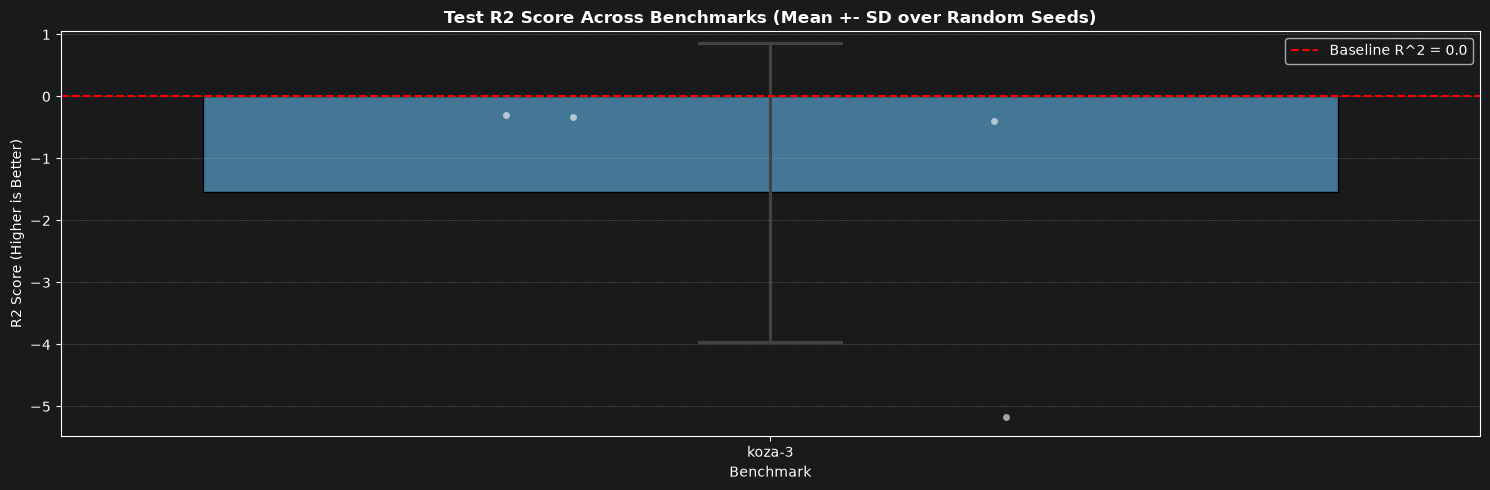

In [34]:
plot_r2_histogram()

In [35]:
# plot_r2_histogram()
# plot_fitness()
# plot_entropy_heatmaps_sessions()
# plot_diversity_entropy()
# plot_solution_data()
plot_entropy_heatmaps_tabs(data_type='Prey Entropy Probability')

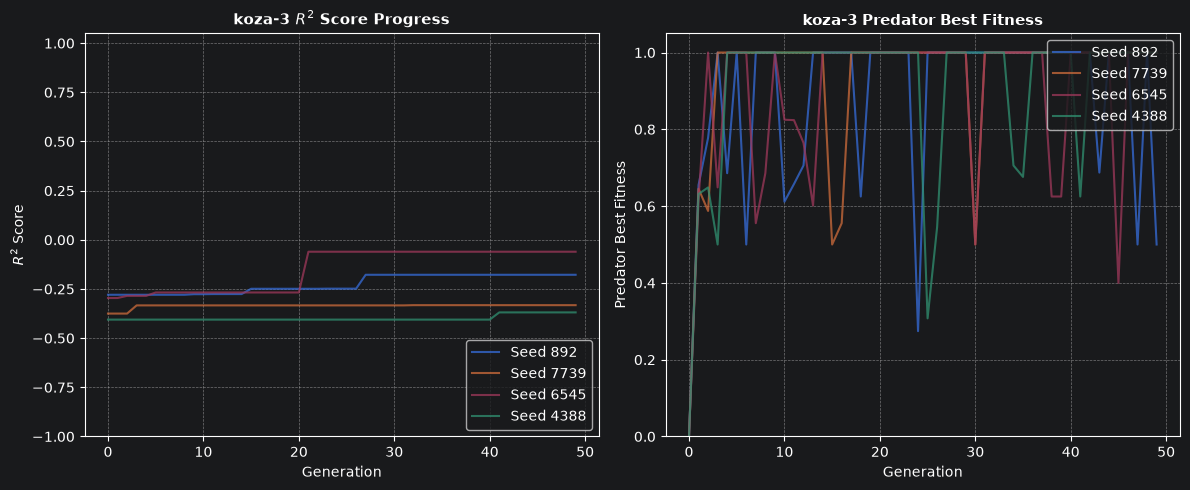

In [36]:
plot_fitness()

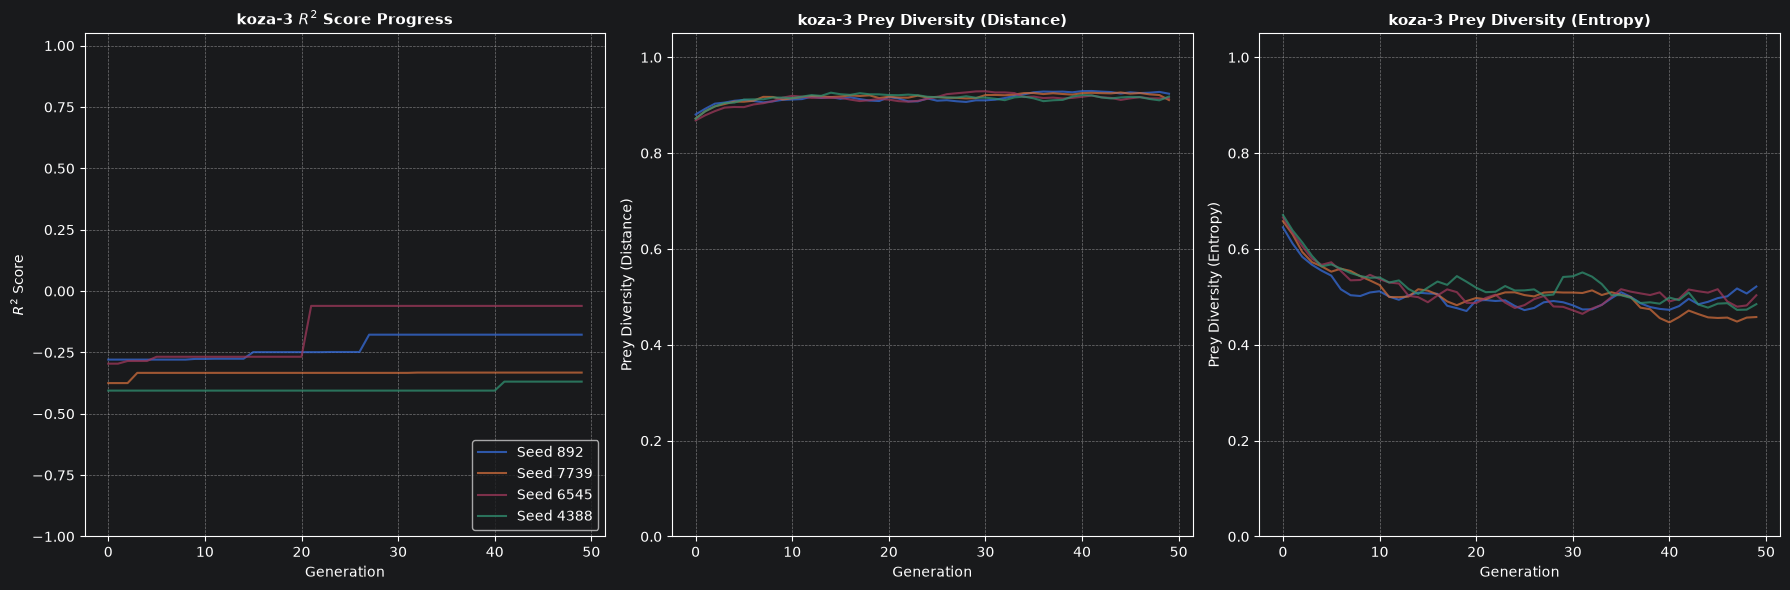

In [37]:
# plot(data1='Prey Diversity Distance', data2='Prey Diversity Entropy', data1_range=(0, 1.05), data2_range=(0, 1.05))

plot_solution_data()

In [38]:
# plot(data1='Predator Best Fitness', data2='Prey Diversity Distance', data1_range=(0, 1.05), data2_range=(0, 1.05))


In [39]:
# results.append({
#     'Seed': seed,
#     'Benchmark': name,
#     'R2_Score': r2,
#     'Formula': str(est_gp._program),
#
#     # Data Per Generation
#     'R2 Score Per Gen': r2_scores,
#     'Parameter': est_gp.get_params(),
#
#     'Prey Average Length': est_gp.run_details_['average_length'],
#     'Prey Average Fitness': est_gp.run_details_['average_fitness'],
#     'Prey Best Fitness': est_gp.run_details_['best_fitness'],
#     'Prey Best Length': est_gp.run_details_['best_length'],
#
#     'Predator Average Length': est_gp.run_details_['pred_average_length'],
#     'Predator Average Fitness': est_gp.run_details_['pred_average_fitness'],
#     'Predator Best Fitness': est_gp.run_details_['pred_best_fitness'],
#     'Predator Best Length': est_gp.run_details_['pred_best_length'],
#
#     'Prey Diversity Distance': est_gp.run_details_['prey_diversity_distance'],
#     'Prey Diversity Entropy': est_gp.run_details_['prey_diversity_entropy'],
#     'Predator Diversity Distance': est_gp.run_details_['pred_diversity_distance'],
#     'Predator Diversity Entropy': est_gp.run_details_['pred_diversity_entropy'],
#
#     'Predator Entropy History': est_gp.run_details_['pred_entropy_history'],
#     'Prey Entropy History': est_gp.run_details_['prey_entropy_history'],
#     'Feature Map': get_feature_map(est_gp._function_set, est_gp.feature_names),
# })